In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import phik
from scipy import stats
import numpy as np

In [ ]:
#1. Загрузим hr.csv в датафрейм
df = pd.read_csv('hr.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
# Посмотрим общую информацию по датасету
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   department             14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.3 MB


In [ ]:
# 2. Рассчитаем основные статистики для переменных
columns = ['satisfaction_level',
 'last_evaluation',
 'number_project',
 'average_montly_hours',
 'time_spend_company',
 'Work_accident',
 'left',
 'promotion_last_5years',]

print(f'Стандартные статистики для числовых переменных\n {'-' * 50}')
for col in columns:
    print(f'Переменная: {col}\n')
    print(f'среднее = {df[col].mean().round(4)}' )
    print(f'медиана = {df[col].median()}' )
    print(f'мода = {df[col].mode()}')
    print(f'минимум = {df[col].min()}')
    print(f'максимум = {df[col].max()}' )
    print(f'среднее отклонение= {df[col].std().round(
        4)}' )
    print(f'\n {'-' * 50}') 

Стандартные статистики для числовых переменных
 --------------------------------------------------
Переменная: satisfaction_level

среднее = 0.6128
медиана = 0.64
мода = 0    0.1
Name: satisfaction_level, dtype: float64
минимум = 0.09
максимум = 1.0
среднее отклонение= 0.2486
satisfaction_level
0.10    358
0.11    335
0.74    257
0.77    252
0.84    247
       ... 
0.25     34
0.28     31
0.27     30
0.12     30
0.26     30
Name: count, Length: 92, dtype: int64

 --------------------------------------------------
Переменная: last_evaluation

среднее = 0.7161
медиана = 0.72
мода = 0    0.55
Name: last_evaluation, dtype: float64
минимум = 0.36
максимум = 1.0
среднее отклонение= 0.1712
last_evaluation
0.55    358
0.50    353
0.54    350
0.51    345
0.57    333
       ... 
0.39     52
0.43     50
0.38     50
0.44     44
0.36     22
Name: count, Length: 65, dtype: int64

 --------------------------------------------------
Переменная: number_project

среднее = 3.8031
медиана = 4.0
мода = 0  

In [ ]:
# 3. Рассчитаем  корреляционную матрицу для количественных переменных.
#  Так как у нас присутствуют не только непрерывные, но так же и порядковые данные (такие как количество проектов, стаж), а так же возможно присутствие выбросов, для расчетов будем
# использовать Коэффициент Кендалла.
columns_matrix = ['satisfaction_level',
 'last_evaluation',
 'number_project',
 'average_montly_hours',
 'time_spend_company']
corr_matrix = df[columns_matrix].corr(method='kendall')
corr_matrix


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company
satisfaction_level,1.000000,0.113865,0.022077,0.051126,-0.110005
last_evaluation,0.113865,1.000000,0.266267,0.235374,0.118842
number_project,0.022077,0.266267,1.000000,0.306987,0.195025
average_montly_hours,0.051126,0.235374,0.306987,1.000000,0.119466
time_spend_company,-0.110005,0.118842,0.195025,0.119466,1.000000


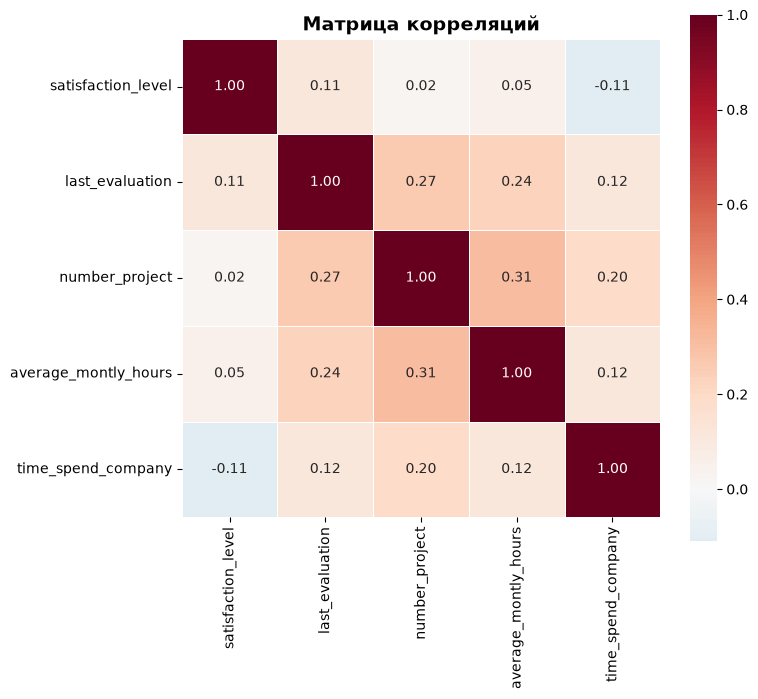

In [ ]:
# Визуализируем получившуюся матрицу

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Матрица корреляций', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> Как мы видим по матрице корреляций, сильных связей здесь не наблюдается. 
> Самые сильные связи замечены между средним количеством часов на рабочем месте в месяц - количеством проектов  и количеством проектов и временем с момента последней оценки.
>  А самые слабые: между количеством проектов и уровнем удовлетворенности, а так же между средним уровнем удовлетворенности и средним количеством часов на рабочем месте в месяц.

In [ ]:
# 4. Рассчитаем сколько сотрудников работает в каждом департаменте
#  Так как стоит задача рассчитать сколько сотрудников работает, то есть на текущий момент, исключим из датафрейма уволившихся сотрудников
df_now = df[df['left']==0]
print(f'Количество сотрудников по департаментам')
df_now.groupby('department')['salary'].size()

Количество сотрудников по департаментам


department
IT              954
RandD           666
accounting      563
hr              524
management      539
marketing       655
product_mng     704
sales          3126
support        1674
technical      2023
Name: salary, dtype: int64

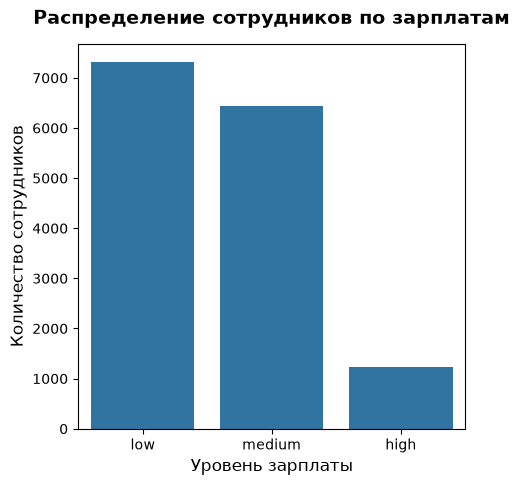

In [66]:
# 5. Посмотрим распределение сотрудников по зарплатам
fig, ax = plt.subplots(figsize = (5,
5))
sns.countplot(data=df, x = 'salary')
ax.set_xlabel('Уровень зарплаты', fontsize=12)
ax.set_ylabel('Количество сотрудников', fontsize=12)
ax.set_title('Распределение сотрудников по зарплатам', fontsize=14, fontweight='bold', y = 1.03)
plt.show()

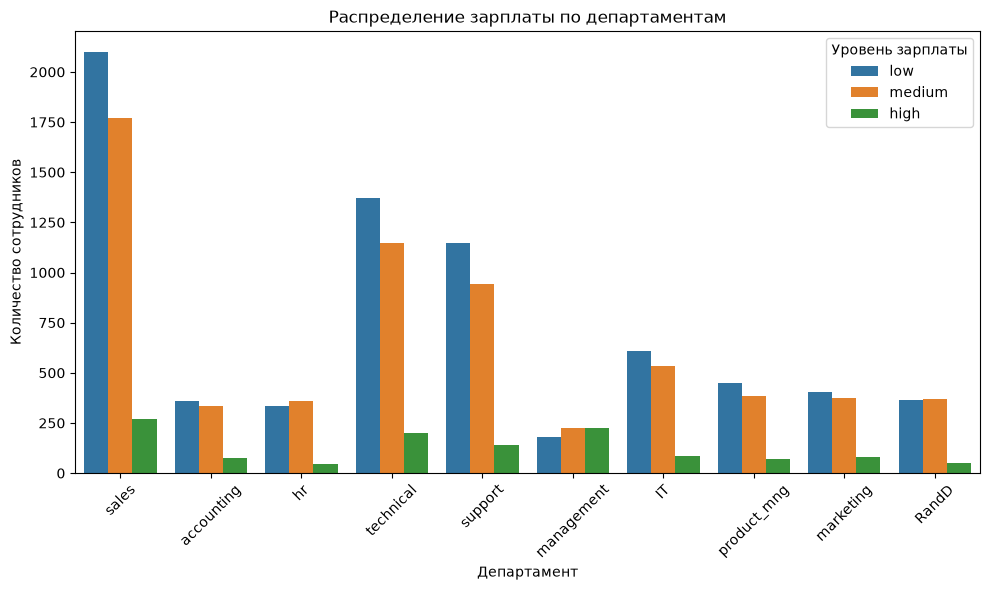

In [90]:
# 6. Посмотрим распределение сотрудников по зарплатам в каждом департаменте по отдельности

fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(data=df, x='department', hue='salary')
plt.xticks(rotation=45)
plt.title('Распределение зарплаты по департаментам')
plt.xlabel('Департамент')
plt.ylabel('Количество сотрудников')
plt.legend(title='Уровень зарплаты')
plt.tight_layout()
plt.show()

In [106]:
# 7. Проверим гипотезу, что сотрудники с высоким окладом проводят на работе больше времени, чем сотрудники с низким окладом



# Разобьем сотрудников на 2 группы: с низким окладом и с высоким окладом
df_low = df[df['salary']=='low']
df_high = df[df['salary']=='high']

# Посчитаем средние значения времени на работе для каждой из групп
mean_low= df_low['average_montly_hours'].mean()
mean_high= df_high['average_montly_hours'].mean()
print(f"Среднее время на рабочем месте у сотрудников с низким окладом: {mean_low:.2f}")
print(f"Среднее время на рабочем месте у сотрудников с высоким окладом: {mean_high:.2f}")


Среднее время на рабочем месте у сотрудников с низким окладом: 201.00
Среднее время на рабочем месте у сотрудников с высоким окладом: 199.87


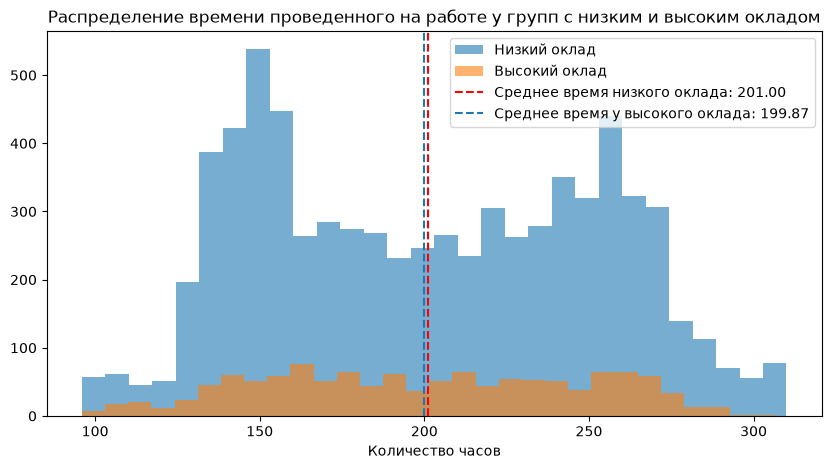

In [107]:

# Сравним распределение времени, проведенного на работе,  для этих двух групп

plt.figure(figsize=(10, 5))

plt.hist(df_low['average_montly_hours'], alpha=0.6, bins=30, label="Низкий оклад")
plt.hist(df_high['average_montly_hours'], alpha=0.6, bins=30, label="Высокий оклад")

plt.axvline(mean_low, linestyle="--", color='red', label=f"Среднее время низкого оклада: {mean_low:.2f}")
plt.axvline(mean_high, linestyle="--", label=f"Среднее время у высокого оклада: {mean_high:.2f}")

plt.title("Распределение времени проведенного на работе у групп с низким и высоким окладом")
plt.xlabel('Количество часов')
plt.ylabel('')
plt.legend()

plt.show()


>Глядя на график распределения, можно предположить, что больше времени на работе проводит группа сотрудников с низким окладом. Проверим так ли это.

> **Сформируем гипотезы:**

> *H₀ - среднее время не различается у групп

> *H₁ - среднее время различается у групп

In [ ]:
# Рассчитаем t - статистику и p-value
t_statistic, p_value= stats.ttest_ind(
    df_low['average_montly_hours'], 
    df_high['average_montly_hours'], 
    equal_var=False  # тест Уэлча
)

print(f"t-статистика: {t_statistic:.3f}")
print(f"p-value: {p_value:.3f}")

t-статистика: 0.762
p-value: 0.446


In [ ]:
# Уровень значимости
alpha = 0.05

# Сравним с p-value и сделаем вывод относительно гипотезы
if p_value < alpha:
    print("Отклоняем нулевую гипотезу.")
    print("Есть статистически значимые основания считать, что среднее время двух групп различается.")
else:
    print("Не отклоняем нулевую гипотезу.")
    print("Недостаточно оснований считать, что среднее время двух групп различается")

Не отклоняем нулевую гипотезу.
Недостаточно оснований считать, что среднее время двух групп различается


In [ ]:
# Чтобы понять насколько мала разница между средним временем, расчитаем размер эффекта (Cohen's d)
pooled_std = np.sqrt(
    (
        ((len(df_low) - 1) * np.var(df_low['average_montly_hours'], ddof=1)) +
        ((len(df_high) - 1) * np.var(df_high['average_montly_hours'], ddof=1))
    )
    /
    (len(df_low) + len(df_high) - 2)
)

cohens_d = (mean_low - mean_high) / pooled_std

print(f"Cohen's d = {cohens_d:.2f}")

Cohen's d = 0.02


In [ ]:
# Выводы по Cohen's d
if abs(cohens_d) < 0.2:
    interpretation = "очень маленький эффект"
elif abs(cohens_d) < 0.5:
    interpretation = "небольшой эффект"
elif abs(cohens_d) < 0.8:
    interpretation = "средний эффект"
else:
    interpretation = "большой эффект"

print(f"Интерпретация: {interpretation}")

Интерпретация: очень маленький эффект


> *H₀: среднее время не различается у групп*
>
> *H₁: среднее время у групп различается*
>
> *t-статистика = 0.762, p-value = 0.446*
>
> *Cohen's d = 0.02*

> По результатам проведенного теста мы не можем отклонить нулевую гипотезу, то есть нет статистически значимых оснований считать, что среднее время проведенное на работе различается между группами с высоким окладом и с низким. Дополнительно проведенный расчет Cohen's d показывает очень маленькое разлисие между этими показателями.

In [161]:
# 8 Рассчитаем следующие показатели среди уволившихся и не уволившихся сотрудников (по отдельности): 
#2. Средняя степень удовлетворенности 3.Среднее количество проектов

# 8.1  Доля сотрудников с повышением за последние 5 лет

portion_promotion = df.groupby('left')['promotion_last_5years'].value_counts(normalize=True).unstack(fill_value=0)

print(f'{'-' * 50}\nДоля сотрудников с повышением за последние 5 лет\n{'-' * 50}')
print(f'Среди не уволившихся сотрудников: {portion_promotion.iloc[0,1]*100:.2f}%')
print(f'Среди уволившихся сотрудников: {portion_promotion.iloc[1,1]*100:.2f}%\n')

# 8.2 Средняя степень удовлетворенности
mean_satisfaction = df.groupby('left')['satisfaction_level'].mean()

print(f'{'-' * 50}\nСредняя степень удовлетворенности\n{'-' * 50}')
print(f'Среди не уволившихся сотрудников: {mean_satisfaction[0]*100:.2f}%')
print(f'Среди уволившихся сотрудников: {mean_satisfaction[1]*100:.2f}%\n')


# 8.3 Среднее количество проектов
mean_project = df.groupby('left')['number_project'].mean()

print(f'{'-' * 50}\nСреднее количество проектов\n{'-' * 50}')
print(f'Среди не уволившихся сотрудников: {mean_project[0]:.2f}')
print(f'Среди уволившихся сотрудников: {mean_project[1]:.2f}')


--------------------------------------------------
Доля сотрудников с повышением за последние 5 лет
--------------------------------------------------
Среди не уволившихся сотрудников: 2.63%
Среди уволившихся сотрудников: 0.53%

--------------------------------------------------
Средняя степень удовлетворенности
--------------------------------------------------
Среди не уволившихся сотрудников: 66.68%
Среди уволившихся сотрудников: 44.01%

--------------------------------------------------
Среднее количество проектов
--------------------------------------------------
Среди не уволившихся сотрудников: 3.79
Среди уволившихся сотрудников: 3.86
